# Dual arbitrary waveform sum/difference capture

This notebook writes two different arbitrary functions to Red Pitaya generator channels `OUT1` and `OUT2`, triggers both channels at the same time, then acquires both input channels with a trigger delay of `8192` samples.

Expected wiring/experiment:
- `OUT1` and `OUT2` are the two input signals to the circuit under test.
- `IN1` measures the sum output.
- `IN2` measures the difference output.
- `IN1` must also see a rising edge above the trigger level because acquisition is triggered from `CH1_PE`.

No alignment is performed here. The captured arrays are saved and plotted exactly as acquired.

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import redpitaya_scpi as scpi

## User settings

Change the IP address, amplitudes, trigger level, and waveform definitions for your setup. The arbitrary waveform values should normally stay in `[-1, +1]`; `AMPLITUDE_CH1` and `AMPLITUDE_CH2` set the output voltage scale.

In [2]:
IP = "169.254.202.253"

DAC_SAMPLE_RATE = 125_000_000
ADC_SAMPLE_RATE = 125_000_000
WAVEFORM_SAMPLES = 16_384
ACQ_SAMPLES = 16_384
DECIMATION = 1
SAMPLE_RATE = ADC_SAMPLE_RATE / DECIMATION

# This frequency makes one AWG point correspond to one 8 ns DAC sample.
FREQUENCY = DAC_SAMPLE_RATE / WAVEFORM_SAMPLES

AMPLITUDE_CH1 = 0.35
AMPLITUDE_CH2 = 0.35
TRIGGER_LEVEL = 0.05
TRIGGER_SOURCE = "CH1_PE"
TRIGGER_DELAY_SAMPLES = 8192
ACQ_TIMEOUT_SECONDS = 10

CAPTURE_DIR = Path("notebook_captures")

## Define the two input functions

Replace `function_ch1` and `function_ch2` with the two functions you want to drive into the experiment. The notebook also calculates the ideal, unaligned sum and difference traces from the commanded AWG waveforms for quick comparison.

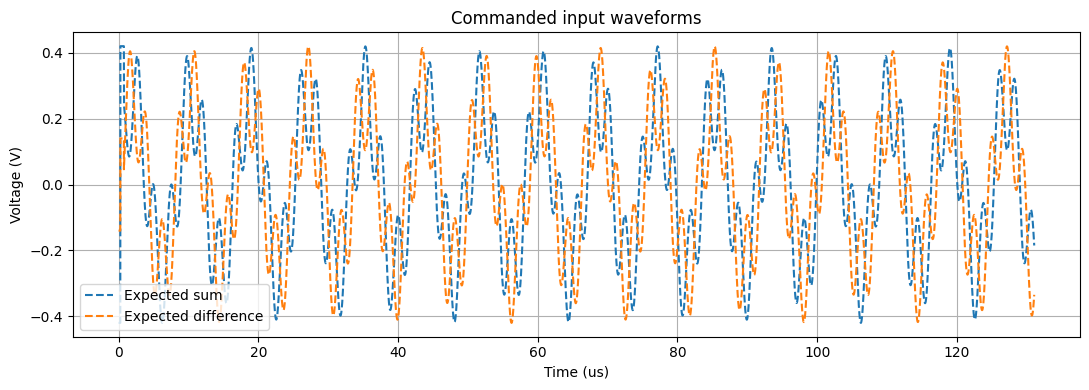

In [4]:
t = np.arange(WAVEFORM_SAMPLES) / DAC_SAMPLE_RATE

# Example inputs. Edit these two lines for your experiment.
function_ch1 = 0.75 * np.sin(2 * np.pi * 120_000 * t)
function_ch2 = 0.45 * np.sin(2 * np.pi * 430_000 * t + 0.4)

# Add a short common rising edge so CH1_PE can trigger reliably.
function_ch1[:32] = -0.8
function_ch1[32:96] = 0.8
function_ch2[:32] = -0.4
function_ch2[32:96] = 0.4

waveform_ch1 = np.clip(function_ch1, -1.0, 1.0)
waveform_ch2 = np.clip(function_ch2, -1.0, 1.0)

input_ch1_v = waveform_ch1 * AMPLITUDE_CH1
input_ch2_v = waveform_ch2 * AMPLITUDE_CH2
expected_sum_v = input_ch1_v + input_ch2_v
expected_difference_v = input_ch1_v - input_ch2_v

plt.figure(figsize=(11, 4))
# plt.plot(t * 1e6, input_ch1_v, label="Input 1 command")
# plt.plot(t * 1e6, input_ch2_v, label="Input 2 command")
plt.plot(t * 1e6, expected_sum_v, "--", label="Expected sum")
plt.plot(t * 1e6, expected_difference_v, "--", label="Expected difference")
plt.xlabel("Time (us)")
plt.ylabel("Voltage (V)")
plt.title("Commanded input waveforms")
plt.grid(True)
plt.legend()
plt.tight_layout()

## Helper functions

In [5]:
def waveform_csv(values: np.ndarray) -> str:
    """Convert a NumPy waveform into the comma-separated format expected by SCPI."""
    return ",".join(f"{value:.5f}" for value in values)


def wait_complete(rp: scpi.scpi) -> None:
    """Wait until previous SCPI commands are complete."""
    rp.txrx_txt("*OPC?")


def configure_generator_channel(rp: scpi.scpi, chan: int, values: np.ndarray, amplitude: float) -> None:
    """Load one arbitrary waveform onto OUT1 or OUT2 and prepare burst triggering."""
    rp.tx_txt(f"SOUR{chan}:FUNC ARBITRARY")
    rp.tx_txt(f"SOUR{chan}:TRAC:DATA:DATA " + waveform_csv(values))
    rp.tx_txt(f"SOUR{chan}:FREQ:FIX {FREQUENCY}")
    rp.tx_txt(f"SOUR{chan}:VOLT {amplitude}")
    rp.tx_txt(f"SOUR{chan}:BURS:STAT BURST")
    rp.tx_txt(f"SOUR{chan}:BURS:NCYC 1")
    rp.tx_txt(f"SOUR{chan}:BURS:NOR 1")
    rp.tx_txt(f"SOUR{chan}:INITValue 0")
    rp.tx_txt(f"SOUR{chan}:BURS:LASTValue 0")
    rp.tx_txt(f"SOUR{chan}:TRig:SOUR INT")


def configure_acquisition(rp: scpi.scpi) -> None:
    """Arm acquisition on both ADC channels with an 8192-sample trigger delay."""
    rp.tx_txt("ACQ:RST")
    rp.tx_txt(f"ACQ:DEC:Factor {DECIMATION}")
    rp.tx_txt("ACQ:DATA:Units VOLTS")
    rp.tx_txt("ACQ:DATA:FORMAT ASCII")
    rp.tx_txt(f"ACQ:TRig:LEV {TRIGGER_LEVEL}")
    rp.tx_txt(f"ACQ:TRig:DLY {TRIGGER_DELAY_SAMPLES}")
    rp.tx_txt("ACQ:START")
    rp.tx_txt(f"ACQ:TRig {TRIGGER_SOURCE}")

    time.sleep(0.01)
    if rp.txrx_txt("ACQ:TRig:STAT?") == "TD":
        raise RuntimeError("Acquisition triggered early. Raise TRIGGER_LEVEL or check the CH1 input/noise.")


def wait_for_acquisition(rp: scpi.scpi, timeout_s: float = ACQ_TIMEOUT_SECONDS) -> None:
    """Wait until the trigger has fired and the acquisition buffer is ready."""
    deadline = time.perf_counter() + timeout_s
    while time.perf_counter() < deadline:
        if rp.txrx_txt("ACQ:TRig:STAT?") == "TD":
            break
        time.sleep(0.001)
    else:
        raise TimeoutError("Acquisition did not trigger before timeout.")

    while time.perf_counter() < deadline:
        if rp.txrx_txt("ACQ:TRig:FILL?") == "1":
            return
        time.sleep(0.001)

    raise TimeoutError("Acquisition buffer did not fill before timeout.")


def read_acquisition_channel(rp: scpi.scpi, chan: int) -> np.ndarray:
    """Read one full ADC buffer from IN1 or IN2."""
    rp.tx_txt(f"ACQ:SOUR{chan}:DATA?")
    raw = rp.rx_txt()
    return np.array(raw.strip("{}\n\r").replace("  ", "").split(","), dtype=np.float64)

## Run simultaneous output and two-channel acquisition

`SOUR:TRig:INT` sends the internal trigger to the generator, so both configured burst channels start together.

In [6]:
rp = scpi.scpi(IP, timeout=15)

try:
    rp.tx_txt("GEN:RST")
    configure_generator_channel(rp, 1, waveform_ch1, AMPLITUDE_CH1)
    configure_generator_channel(rp, 2, waveform_ch2, AMPLITUDE_CH2)
    rp.tx_txt("OUTPUT:STATE ON")
    wait_complete(rp)

    configure_acquisition(rp)

    start = time.perf_counter()
    rp.tx_txt("SOUR:TRig:INT")
    time.sleep((WAVEFORM_SAMPLES / DAC_SAMPLE_RATE) + 0.005)
    wait_for_acquisition(rp)
    captured_sum = read_acquisition_channel(rp, 1)
    captured_difference = read_acquisition_channel(rp, 2)
    elapsed = time.perf_counter() - start

finally:
    rp.close()

print(f"Capture elapsed from shared trigger command to read complete: {elapsed * 1e3:.3f} ms")
print(f"IN1 sum min/max: {np.min(captured_sum):.4f} V / {np.max(captured_sum):.4f} V")
print(f"IN2 difference min/max: {np.min(captured_difference):.4f} V / {np.max(captured_difference):.4f} V")

Capture elapsed from shared trigger command to read complete: 577.914 ms
IN1 sum min/max: -0.2159 V / 0.3236 V
IN2 difference min/max: -0.2947 V / 0.1305 V


## Save and plot raw captures

The captured sum and difference are not aligned or shifted. The expected traces are plotted on their own AWG time axis only as a reference for the commanded waveforms.

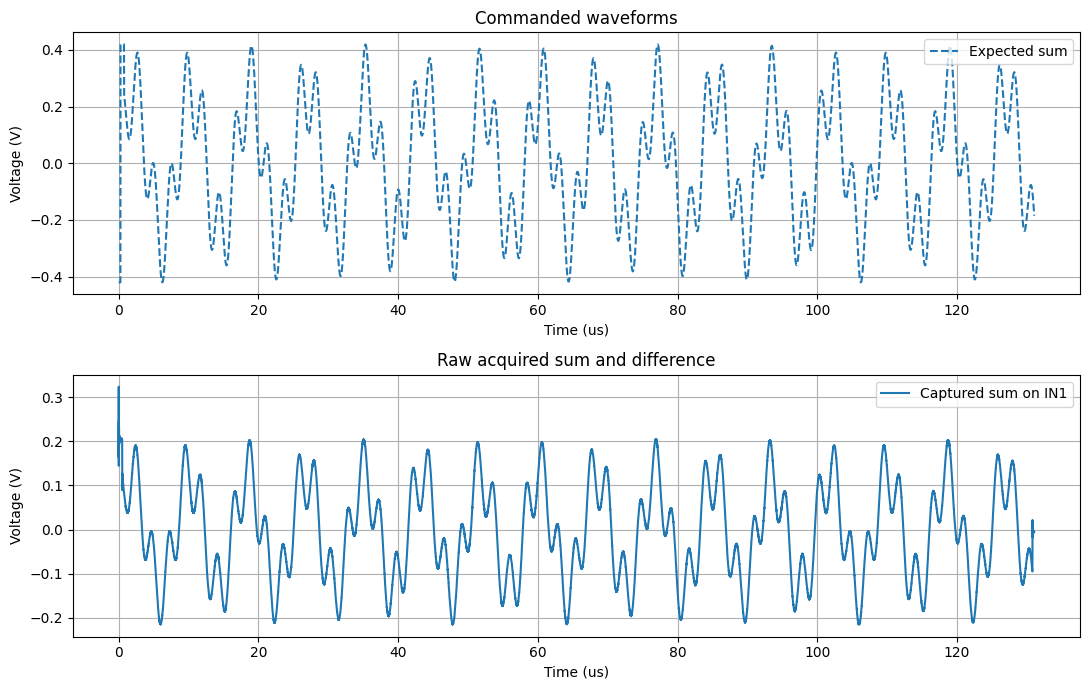

Saved: notebook_captures\dual_commanded_inputs.csv
Saved: notebook_captures\dual_captured_sum_difference.csv
Saved: notebook_captures\dual_sum_difference_capture.png


In [11]:
CAPTURE_DIR.mkdir(exist_ok=True)

capture_time_us = np.arange(len(captured_sum)) / SAMPLE_RATE * 1e6
command_time_us = t * 1e6

np.savetxt(
    CAPTURE_DIR / "dual_commanded_inputs.csv",
    np.column_stack((command_time_us, input_ch1_v, input_ch2_v, expected_sum_v, expected_difference_v)),
    delimiter=",",
    header="time_us,input_1_v,input_2_v,expected_sum_v,expected_difference_v",
    comments="",
)

np.savetxt(
    CAPTURE_DIR / "dual_captured_sum_difference.csv",
    np.column_stack((capture_time_us, captured_sum, captured_difference)),
    delimiter=",",
    header="time_us,captured_sum_in1_v,captured_difference_in2_v",
    comments="",
)

_, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)

# axes[0].plot(command_time_us, input_ch1_v, label="Input 1 command")
# axes[0].plot(command_time_us, input_ch2_v, label="Input 2 command")
axes[0].plot(command_time_us, expected_sum_v, "--", label="Expected sum")
# axes[0].plot(command_time_us, expected_difference_v, "--", label="Expected difference")
axes[0].set_title("Commanded waveforms")
axes[0].set_xlabel("Time (us)")
axes[0].set_ylabel("Voltage (V)")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(capture_time_us, captured_sum, label="Captured sum on IN1")
# axes[1].plot(capture_time_us, captured_difference, label="Captured difference on IN2")
axes[1].set_title("Raw acquired sum and difference")
axes[1].set_xlabel("Time (us)")
axes[1].set_ylabel("Voltage (V)")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.savefig(CAPTURE_DIR / "dual_sum_difference_capture.png", dpi=150)
plt.show()

print(f"Saved: {CAPTURE_DIR / 'dual_commanded_inputs.csv'}")
print(f"Saved: {CAPTURE_DIR / 'dual_captured_sum_difference.csv'}")
print(f"Saved: {CAPTURE_DIR / 'dual_sum_difference_capture.png'}")